In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("../data/train.csv")
df_t = pd.read_csv("../data/test.csv")

In [3]:
df.head()

,id,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,...,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender,Customer Type,Type of Travel,Class,satisfaction
0,0,36,694,4,4,4,3,1,4,1,...,4,3,1,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
1,1,56,651,5,5,5,5,5,4,4,...,5,4,3,0,0.0,Male,Loyal Customer,Business travel,Business,True
2,2,31,1371,3,4,2,5,3,3,3,...,4,5,3,0,0.0,Female,Loyal Customer,Personal Travel,Eco,False
3,3,10,1616,3,5,3,3,3,3,3,...,3,4,3,0,0.0,Male,Loyal Customer,Personal Travel,Eco,False
4,4,23,481,3,4,3,4,5,3,5,...,5,3,5,5,0.0,Female,disloyal Customer,Business travel,Eco,False


In [4]:
test_ids = df_t["id"].copy()

df.drop(["id"], axis=1, inplace=True)
df_t.drop(["id"], axis=1, inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699635 entries, 0 to 699634
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   Age                                699635 non-null  int64  
 1   Flight Distance                    699635 non-null  int64  
 2   Inflight wifi service              699635 non-null  int64  
 3   Departure/Arrival time convenient  699635 non-null  int64  
 4   Ease of Online booking             699635 non-null  int64  
 5   Gate location                      699635 non-null  int64  
 6   Food and drink                     699635 non-null  int64  
 7   Online boarding                    699635 non-null  int64  
 8   Seat comfort                       699635 non-null  int64  
 9   Inflight entertainment             699635 non-null  int64  
 10  On-board service                   699635 non-null  int64  
 11  Leg room service                   6996

In [6]:
df.isnull().sum()

Age                                    0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             292
Gender                                 0
Customer Type                          0
Type of Travel                         0
Class                                  0
satisfaction                           0
dtype: int64

In [7]:
df['satisfaction'].value_counts(normalize = True)

satisfaction
False    0.556427
True     0.443573
Name: proportion, dtype: float64

In [8]:
df['Gender'].value_counts(normalize = True)

Gender
Male      0.502666
Female    0.497334
Name: proportion, dtype: float64

In [9]:
pd.crosstab(
    df["Gender"],
    df["satisfaction"],
    normalize="index"
) * 100

satisfaction,False,True
Gender,,
Female,56.200568,43.799432
Male,55.090806,44.909194


In [10]:
df['Customer Type'].value_counts(normalize = True)

Customer Type
Loyal Customer       0.824701
disloyal Customer    0.175299
Name: proportion, dtype: float64

In [11]:
pd.crosstab(
    df["Customer Type"],
    df["satisfaction"],
    normalize="index"
) * 100

satisfaction,False,True
Customer Type,,
Loyal Customer,50.485450,49.514550
disloyal Customer,79.905418,20.094582


In [12]:
df['Type of Travel'].value_counts(normalize = True)

Type of Travel
Business travel    0.711001
Personal Travel    0.288999
Name: proportion, dtype: float64

In [13]:
pd.crosstab(
    df["Type of Travel"],
    df["satisfaction"],
    normalize="index"
) * 100

satisfaction,False,True
Type of Travel,,
Business travel,41.566337,58.433663
Personal Travel,90.273698,9.726302


In [14]:
df['Class'].value_counts(normalize = True)

Class
Business    0.489129
Eco         0.467964
Eco Plus    0.042907
Name: proportion, dtype: float64

In [15]:
pd.crosstab(
    df["Class"],
    df["satisfaction"],
    normalize="index"
) * 100

satisfaction,False,True
Class,,
Business,27.468937,72.531063
Eco,83.244249,16.755751
Eco Plus,75.782005,24.217995


In [16]:
df.describe()

,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes
count,699635.000000,699635.000000,699635.000000,699635.00000,699635.00000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699635.000000,699343.000000
mean,39.001928,1353.778702,2.778722,3.15621,2.81324,3.013734,3.265644,3.364156,3.568950,3.453910,3.517404,3.472847,3.805443,3.420291,3.380401,1.176209,1.134280
std,13.800943,954.422566,1.280419,1.47539,1.32955,1.254014,1.300202,1.288538,1.275333,1.308157,1.238474,1.271755,1.079175,1.210604,1.277870,5.982187,5.749304
min,7.000000,67.000000,0.000000,0.00000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,631.000000,2.000000,2.00000,2.00000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,954.000000,3.000000,3.00000,3.00000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,0.000000,0.000000
75%,50.000000,1814.000000,4.000000,4.00000,4.00000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.000000,0.000000,0.000000
max,85.000000,4983.000000,5.000000,5.00000,5.00000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,489.000000,491.000000


In [ ]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include = ['int', 'float']).columns

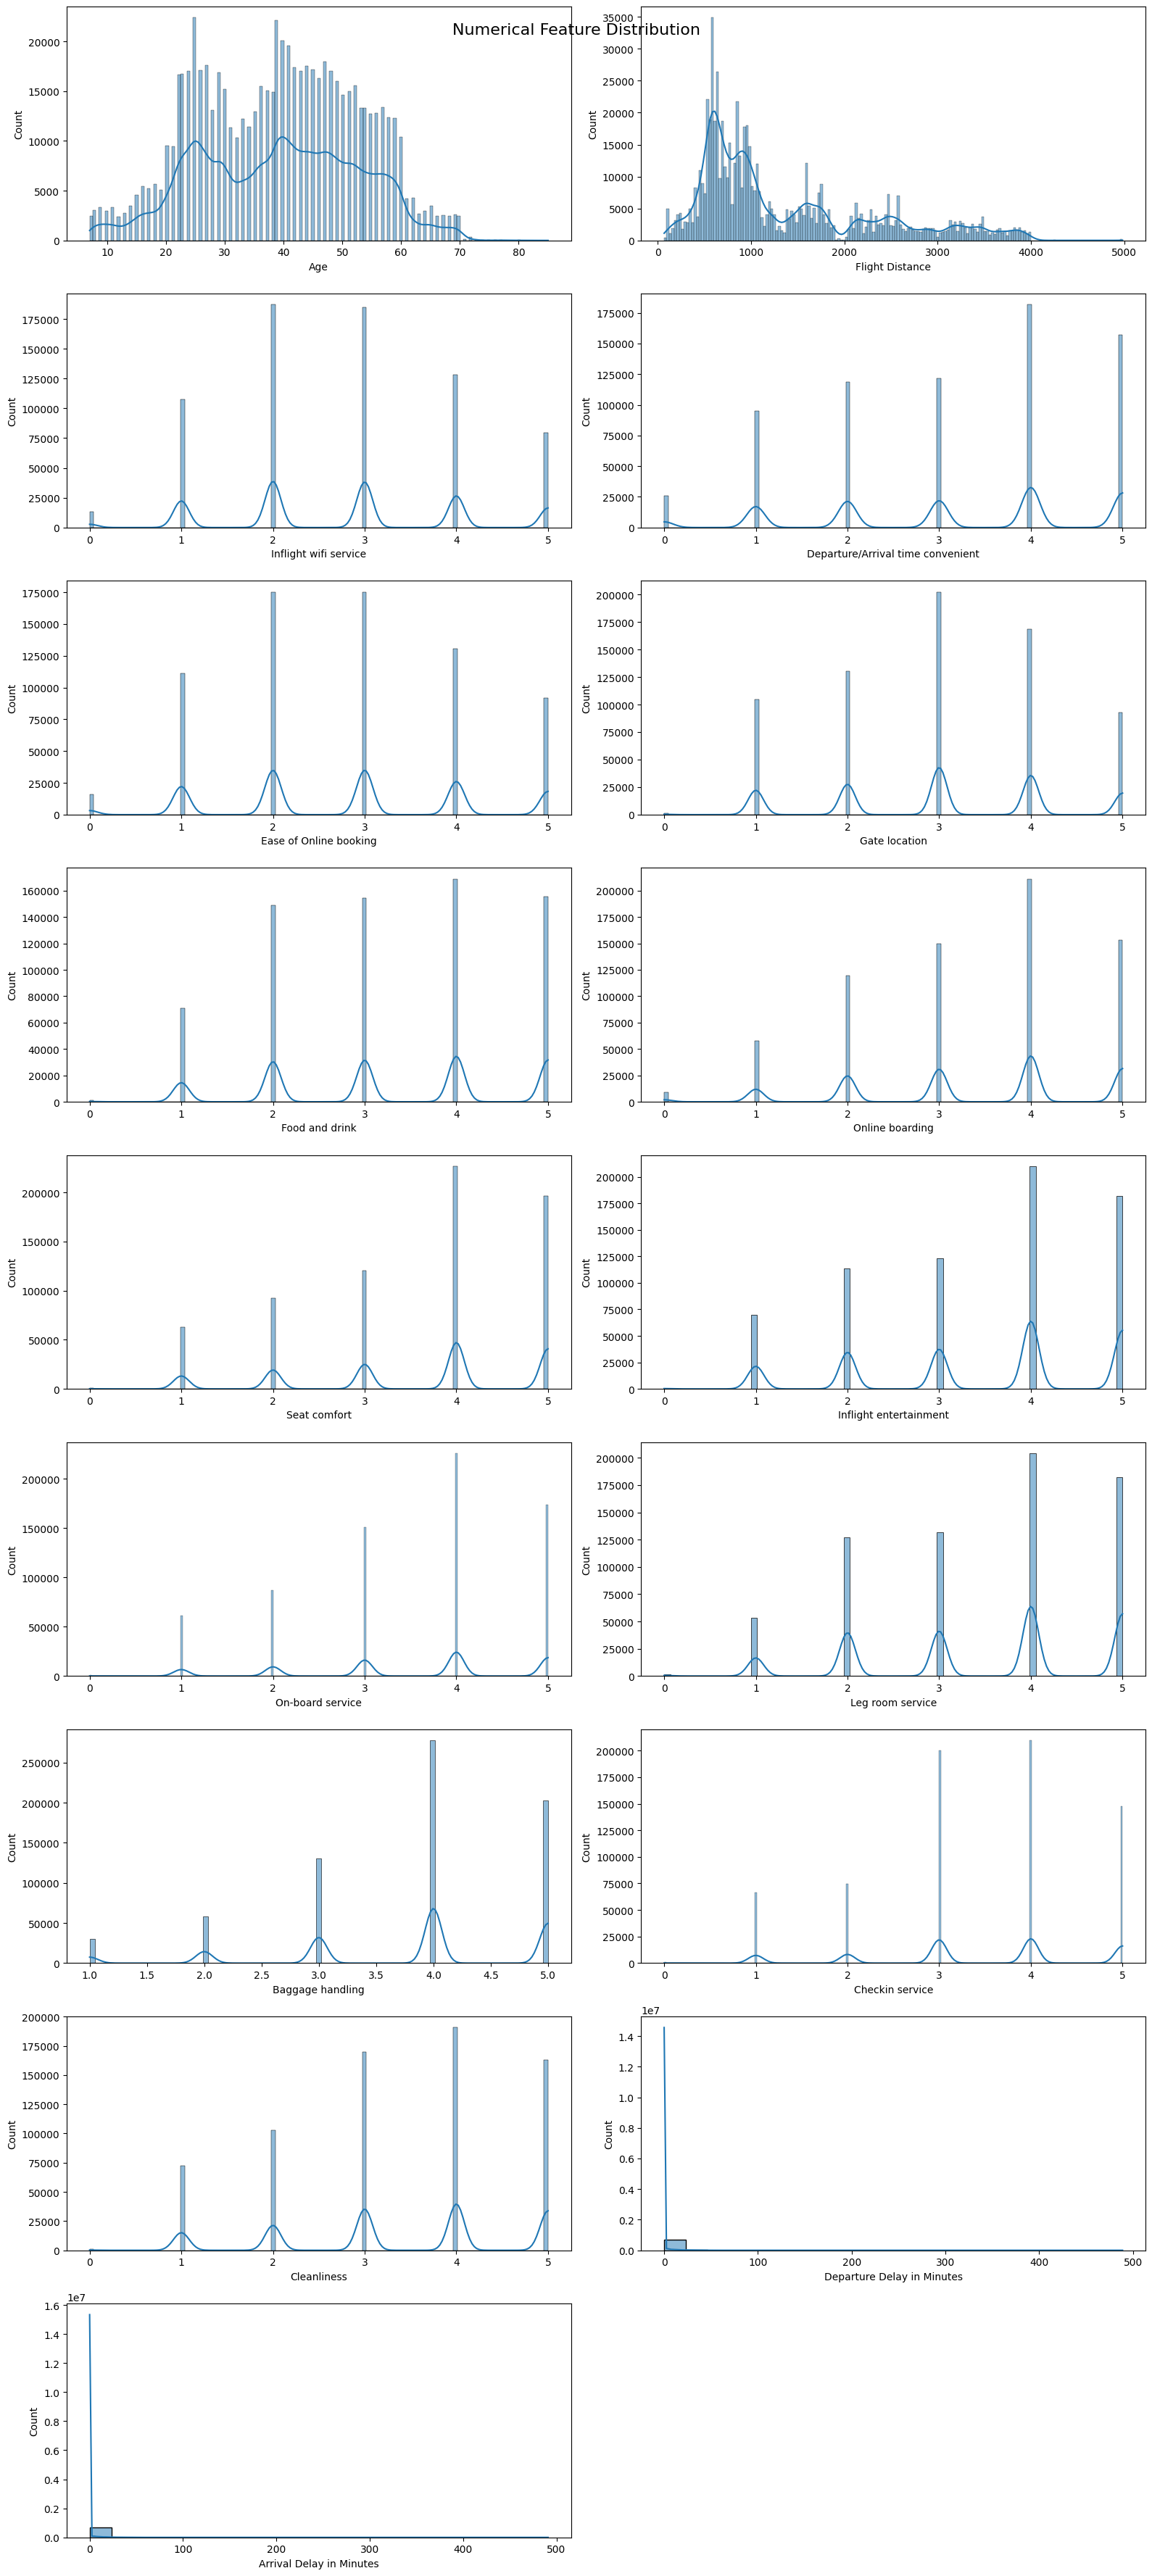

In [18]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
fig.suptitle('Numerical Feature Distribution', fontsize=16)

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

# Hide unused subplots
for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [19]:
zero_count = (df["Departure Delay in Minutes"] == 0).sum()
non_zero_count = (df["Departure Delay in Minutes"] != 0).sum()
total = len(df)

print(f"No delay: {zero_count/total}")
print(f"Delay: {non_zero_count/total}")

No delay: 0.9078333702573484
Delay: 0.09216662974265152


In [20]:
zero_count = (df["Arrival Delay in Minutes"] == 0).sum()
non_zero_count = (df["Arrival Delay in Minutes"] != 0).sum()
total = len(df)

print(f"No delay: {zero_count/total}")
print(f"Delay: {non_zero_count/total}")

No delay: 0.915355864129153
Delay: 0.08464413587084695


In [21]:
df[df["Arrival Delay in Minutes"].isna()]["satisfaction"].value_counts(normalize=True)

satisfaction
False    0.636986
True     0.363014
Name: proportion, dtype: float64

In [22]:
df[df["Arrival Delay in Minutes"] == 0]["satisfaction"].value_counts(normalize=True)

satisfaction
False    0.547896
True     0.452104
Name: proportion, dtype: float64

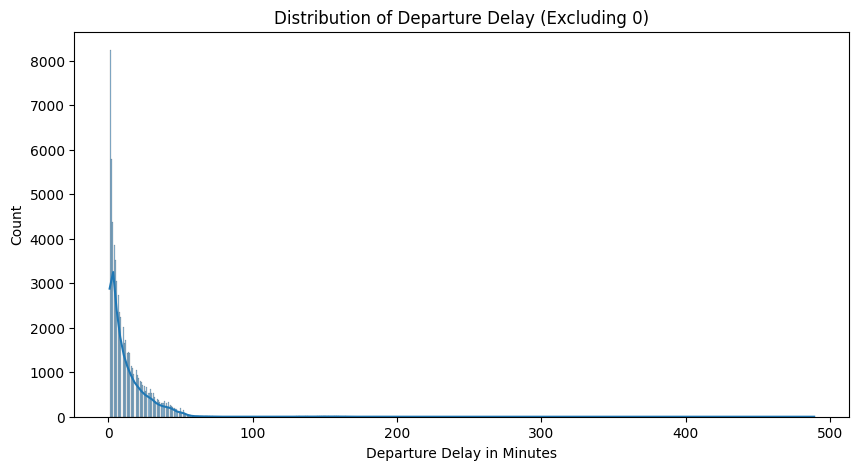

In [23]:
df_delay = df.copy()
df_delay = df_delay[df_delay["Departure Delay in Minutes"] != 0].copy()

plt.figure(figsize=(10, 5))
sns.histplot(df_delay["Departure Delay in Minutes"], kde=True)

plt.title("Distribution of Departure Delay (Excluding 0)")
plt.xlabel("Departure Delay in Minutes")
plt.ylabel("Count")
plt.show()

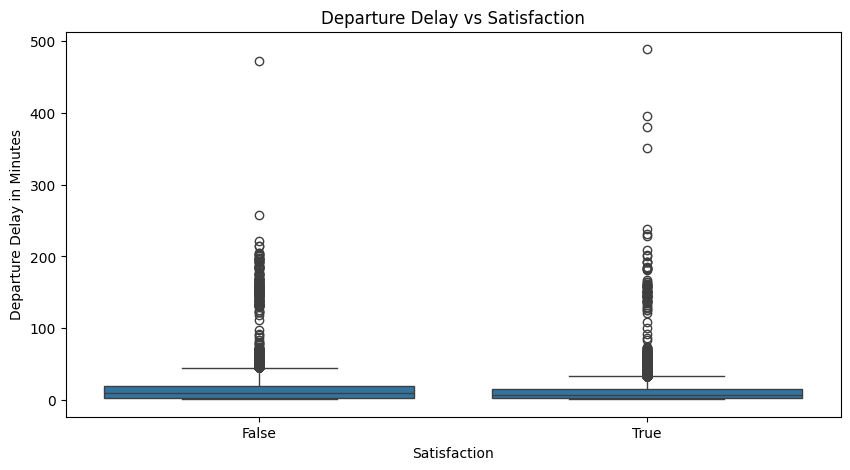

In [24]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_delay, x="satisfaction", y="Departure Delay in Minutes")

plt.title("Departure Delay vs Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Departure Delay in Minutes")
plt.show()

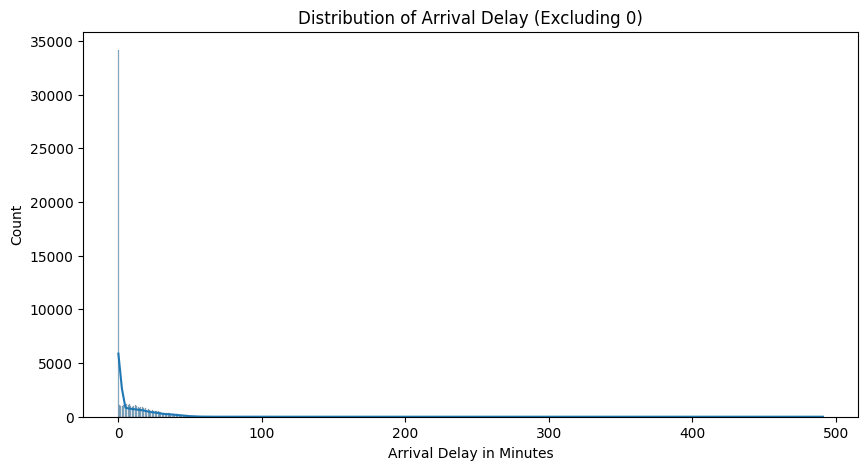

In [25]:
df_arr_delay = df[df["Arrival Delay in Minutes"].notna() & (df["Arrival Delay in Minutes"] != 0)].copy()

plt.figure(figsize=(10, 5))
sns.histplot(df_delay["Arrival Delay in Minutes"], kde=True)

plt.title("Distribution of Arrival Delay (Excluding 0)")
plt.xlabel("Arrival Delay in Minutes")
plt.ylabel("Count")
plt.show()

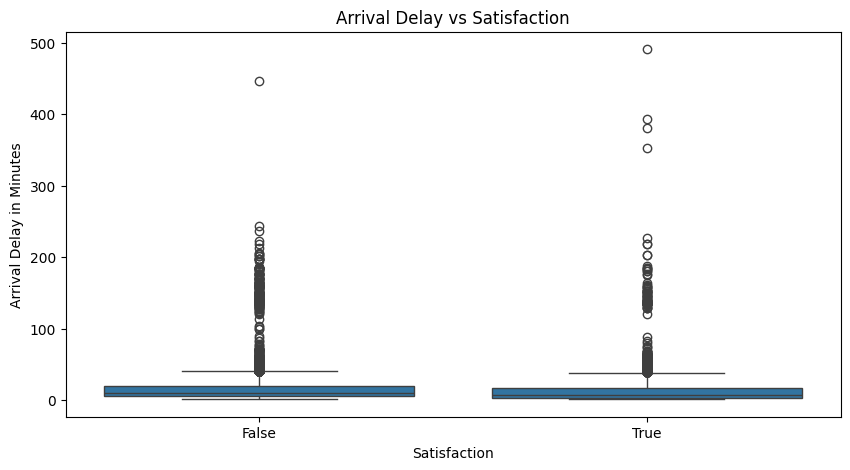

In [26]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df_arr_delay, x="satisfaction", y="Arrival Delay in Minutes")

plt.title("Arrival Delay vs Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Arrival Delay in Minutes")
plt.show()

In [28]:
num_cols = num_cols.drop([
    "Arrival Delay in Minutes",
    "Departure Delay in Minutes"
])

In [29]:
num_cols

Index(['Age', 'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Cleanliness'],
      dtype='object')

In [30]:
df[["Departure Delay in Minutes", "Arrival Delay in Minutes"]].corr()

,Departure Delay in Minutes,Arrival Delay in Minutes
Departure Delay in Minutes,1.000000,0.842034
Arrival Delay in Minutes,0.842034,1.000000


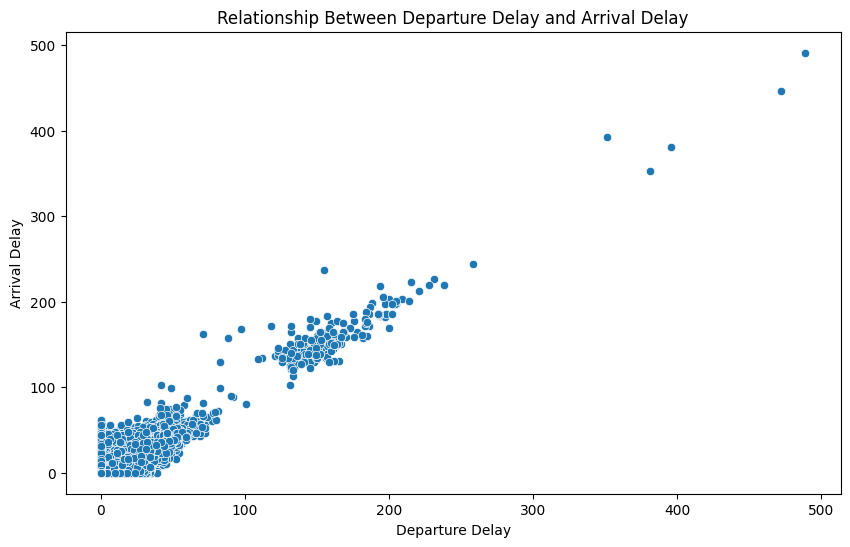

In [31]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Departure Delay in Minutes",
    y="Arrival Delay in Minutes"
)

plt.title("Relationship Between Departure Delay and Arrival Delay")
plt.xlabel("Departure Delay")
plt.ylabel("Arrival Delay")
plt.show()

In [32]:
df["Delay_on_Air"] = df["Arrival Delay in Minutes"] - df["Departure Delay in Minutes"]

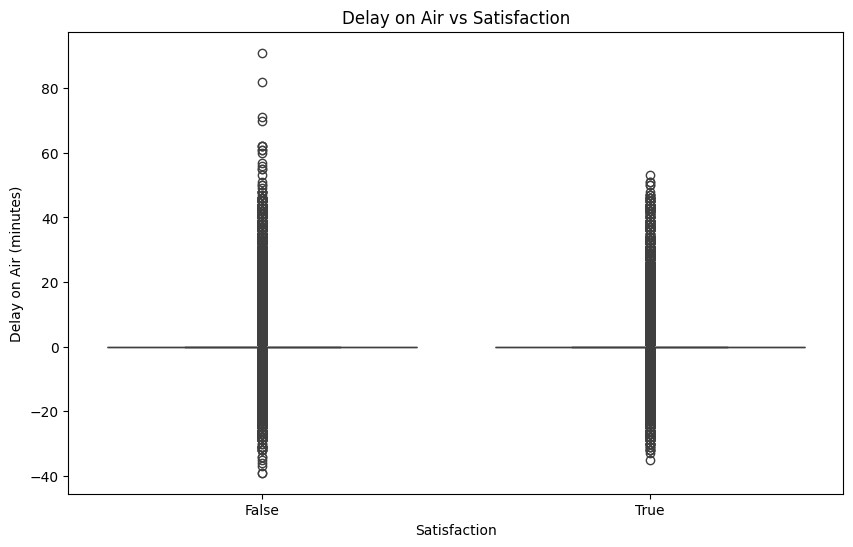

In [33]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="satisfaction",
    y="Delay_on_Air"
)

plt.title("Delay on Air vs Satisfaction")
plt.xlabel("Satisfaction")
plt.ylabel("Delay on Air (minutes)")
plt.show()

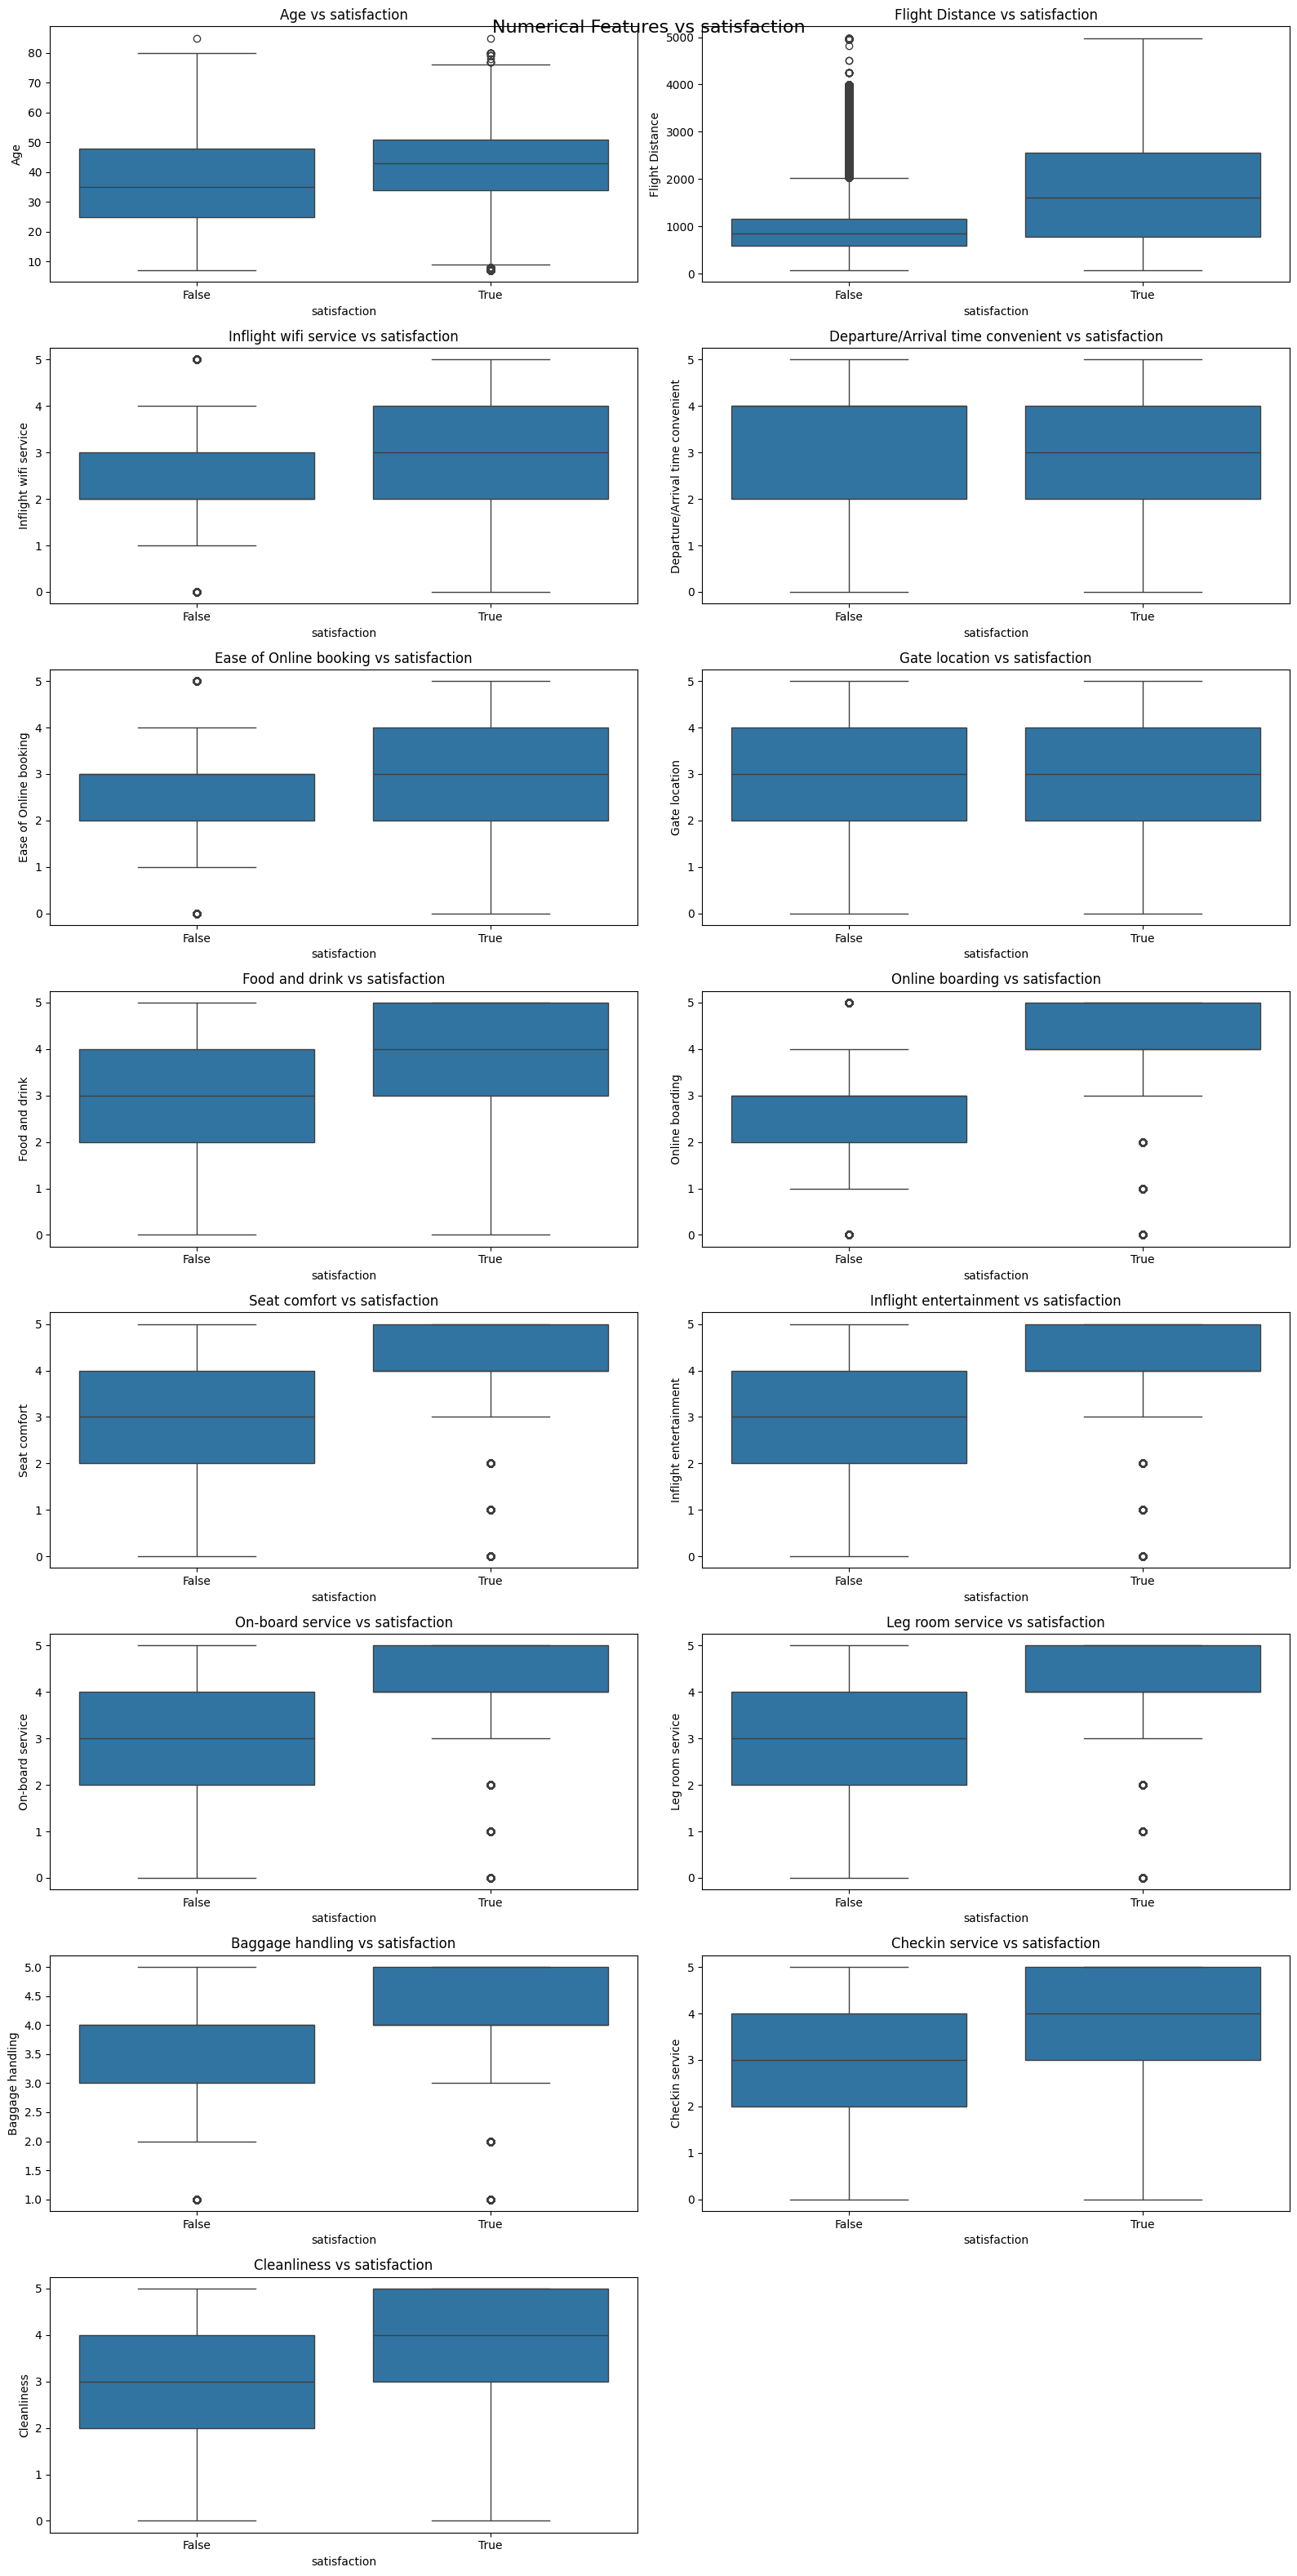

In [34]:
n_cols = 2
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()
fig.suptitle('Numerical Features vs satisfaction', fontsize=16)

for i, col in enumerate(num_cols):
    ax = axes[i]
    sns.boxplot(data=df, x='satisfaction', y=col, ax=ax)
    ax.set_title(f'{col} vs satisfaction')
    ax.set_xlabel('satisfaction')
    ax.set_ylabel(col)

# Hide unused subplot
for i in range(len(num_cols), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [35]:
def numerical_target_analysis(df, feature, target, q=10):

    print(f"\n{'='*60}")
    print(f"Feature: {feature}")

    print("\nTarget group statistics:")

    print(
        df.groupby(target)[feature]
        .agg(["mean", "median", "std", "min", "max", "count"])
    )

    temp = df[[feature, target]].copy()

    temp["bin"] = pd.qcut(
        temp[feature],
        q=q,
        duplicates="drop"
    )

    print("\nTarget probability by feature bin:")

    print(
        temp.groupby("bin", observed=True)[target]
        .agg(["mean", "count"])
    )

In [37]:
target = "satisfaction"

num_cols = (
    df.select_dtypes(include="number")
    .columns
    .drop([target, "id"], errors="ignore")
    .tolist()
)

for col in num_cols:
    numerical_target_analysis(df, col, target)


Feature: Age

Target group statistics:
                   mean  median        std  min  max   count
satisfaction                                                
False         36.504131    35.0  14.858662    7   85  389296
True          42.135220    43.0  11.610186    7   85  310339

Target probability by feature bin:
                   mean  count
bin                           
(6.999, 22.0]  0.205626  85218
(22.0, 25.0]   0.315656  56156
(25.0, 30.0]   0.338952  79908
(30.0, 36.0]   0.357375  73788
(36.0, 40.0]   0.483373  72141
(40.0, 43.0]   0.622526  53972
(43.0, 47.0]   0.608039  68966
(47.0, 52.0]   0.593623  78186
(52.0, 57.0]   0.608347  65553
(57.0, 85.0]   0.379318  65747

Feature: Flight Distance

Target group statistics:
                     mean  median          std  min   max   count
satisfaction                                                     
False         1038.448556   841.0   716.973683   67  4983  389296
True          1749.335704  1605.0  1061.872046   67  4983 

<Axes: >

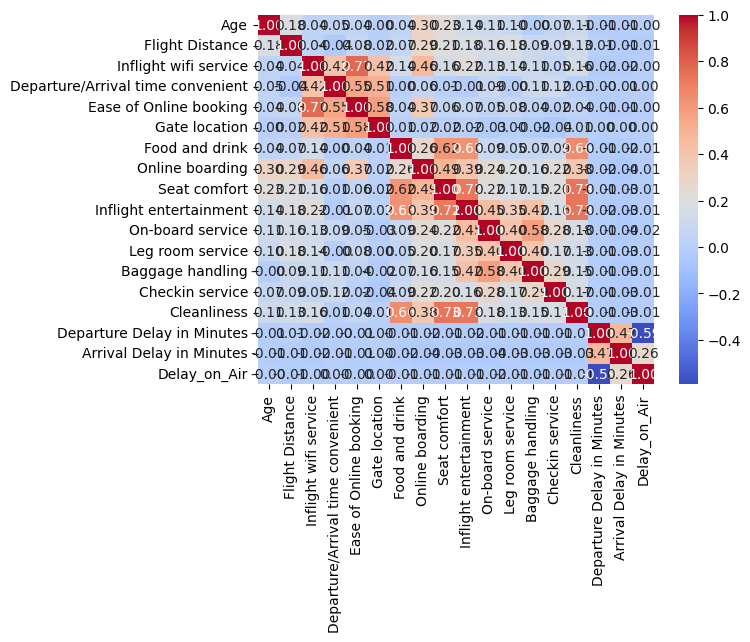

In [38]:
cor = df[num_cols].corr(method = 'spearman') #use spearman because it tell also tell if there is any non linear relationship between the features

sns.heatmap(cor, annot=True, cmap='coolwarm', fmt=".2f")

Key Findings:-
Dataset is balanced

Categorical columns:- Gender can be dropped, others are very important features.

Numerical columns:- 
Gate location can be dropped

Make arrival delay and departure delay as categorical columns with 3 classes (no delay, 1-90 minutes, more than 90 minutes) -> corr is 0.84


Handling Missing Values:- fill the missing values in 'Arrival Delay in Minutes' with 0 (Mode)

In [39]:
left_skewed = []
right_skewed = []
for cols in num_cols:
    if df[cols].skew() > 0.5:
        print(f"{cols} is skewed with skewness: {df[cols].skew()}")
        right_skewed.append(cols)

    elif df[cols].skew() < -0.5:
        print(f"{cols} is negatively skewed with skewness: {df[cols].skew()}")
        left_skewed.append(cols)


print(f"Left skewed features: {left_skewed}")
print(f"Right skewed features: {right_skewed}")

Flight Distance is skewed with skewness: 1.0804656071734196
Seat comfort is negatively skewed with skewness: -0.6161920579994616
On-board service is negatively skewed with skewness: -0.5593974280113893
Baggage handling is negatively skewed with skewness: -0.8388565290421319
Departure Delay in Minutes is skewed with skewness: 12.87216306969923
Arrival Delay in Minutes is skewed with skewness: 13.317512789888804
Delay_on_Air is skewed with skewness: 2.10599987694359
Left skewed features: ['Seat comfort', 'On-board service', 'Baggage handling']
Right skewed features: ['Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Delay_on_Air']
